# Import Libraries
Pada tahap ini, kami menginisialisasi seluruh pustaka (libraries) yang akan menjadi mesin utama pengolahan data dan pemodelan, seperti Pandas untuk manipulasi dataframe dan Scikit-Learn untuk algoritma Machine Learning.

In [2]:
import pandas as pd #Untuk manipulasi data
import numpy as np #Untuk operasi matematika
import matplotlib.pyplot as plt #untuk visualisasi data
import seaborn as sns #untuk visualisasi data
from sklearn.pipeline import Pipeline #untuk membuat pipeline
from sklearn.compose import ColumnTransformer #untuk menggabungkan beberapa transformer
from sklearn.impute import SimpleImputer #untuk mengisi nilai yang hilang
from sklearn.preprocessing import StandardScaler, OneHotEncoder #untuk melakukan scaling dan encoding
from sklearn.base import BaseEstimator, TransformerMixin #untuk membuat transformer custom
from lightgbm import LGBMClassifier #untuk membuat model LightGBM
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score #untuk evaluasi model

In [3]:
df = pd.read_csv('https://raw.githubusercontent.com/micelll/SPARC-2026/main/SPARC_dataset.csv')
df

C:\Users\Yosuke\AppData\Local\Temp\ipykernel_14944\2419774282.py:1: DtypeWarning: Columns (3,19,23,24,26) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('https://raw.githubusercontent.com/micelll/SPARC-2026/main/SPARC_dataset.csv')


,Customer ID,Kelurahan,Kecamatan,Kode POS,Cash/Credit,Kode Dealer,Finance Company,Tenor,Gender,Tgl Lahir,...,range dp,wilayah,9 segment,kode motor,OTR,tahun rakit,DLR group,tgl cetak,tgl mohon,Kode Kota-Provinsi
0,CUST-159769,Baru Ilir,Balikpapan Barat,76131,2.0,12756.0,4,3,2,1992-03-03 0:00:00,...,2 - 3 juta,6471,AT LOW,HN,18685000.0,NaN,NaN,NaN,02-01-2019,6471-6400
1,CUST-164551,BARU TENGAH,BALIKPAPAN BARAT,76132,2.0,733.0,1,1,2,1991-04-27 0:00:00,...,3 jt up,6471,AT LOW,HN,18685000.0,NaN,NaN,NaN,02012019,6471-6400
2,CUST-159733,BARU TENGAH,BALIKPAPAN BARAT,76132,1.0,733.0,N,N,2,1982-01-04 0:00:00,...,kurang 1 juta,6471,AT MID,HR,20775000.0,NaN,NaN,NaN,02012019,6471-6400
3,CUST-164422,BARU TENGAH,BALIKPAPAN BARAT,76132,1.0,733.0,N,N,2,1997-06-26 0:00:00,...,krg 1 jt,6471,AT MID,HR,20775000.0,NaN,NaN,NaN,02012019,6471-6400
4,CUST-155472,Baru Ulu,Balikpapan Barat,76133,2.0,11160.0,1,2,1,1996-07-12 0:00:00,...,2 - 3 jt,6471,AT MID,HR,20775000.0,NaN,NaN,NaN,02-01-2019,6471-6400
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
319973,CUST-122157,WARU,WARU,76284,1.0,10440.0,N,N,1,2006-01-06 0:00:00,...,krg 1 jt,6409.0,AT LOW,MM,22550000.0,2025,NaN,NaN,31122025,6409-6400
319974,CUST-133749,WARU,WARU,76284,2.0,1587.0,1,2,2,1992-09-18 0:00:00,...,1 - 2 juta,6409.0,AT LOW,MO,21810000.0,2025,NaN,NaN,31-12-2025,6409-6400
319975,CUST-253560,WARU,WARU,76284,2.0,1587.0,1,3,1,1988-07-25 0:00:00,...,3 jt up,6409.0,AT LOW,MO,21810000.0,2025,NaN,NaN,31122025,6409-6400
319976,CUST-133980,WARU,WARU,76284,2.0,6481.0,1,2,2,2005-09-24 0:00:00,...,1 - 2 jt,6409.0,AT MID,MT,24310000.0,2025,NaN,NaN,31122025,6409-6400


# Data Cleaning

In [4]:
df = df.dropna(subset=['Customer ID']).reset_index(drop=True) 
df = df.drop(columns = ['tahun rakit', 'DLR group', 'tgl cetak']).reset_index(drop=True)
df = df.drop(columns=['Tgl Lahir', 'tgl mohon'])
df = df.drop(columns=['range dp'])
df = df.iloc[:-1].reset_index(drop=True)

# Data Formatting

In [5]:
tipe_pembayaran = { #Mengubah angka 1 di kolom cash/credit menjadi cash dan angka 2 menjadi credit, untuk memudahkan visualisasi
    1 : 'Cash',
    2 : 'Credit'
}

df['Cash/Credit'] = df['Cash/Credit'].map(tipe_pembayaran)

df.loc[df['Cash/Credit'] == 'Cash', 'Tenor'] = 'N' #Memastikan bahwa jika pembayaran tunai, maka tenor otomatis jadi 'N' (Non-Installment)

#Mengubah tipe data jadi string karena isinya kode kategori agar tidak dihitung secara matematis, tapi tetap bisa dihitung frekuensinya saja
df['Kode Dealer'] = df['Kode Dealer'].astype(str)

#Kolom yang berisi nilai uang, kita ubah ke numerik setelah dibersihkan dari simbol dan spasi
kolom_uang = ['dp aktual', 'cicilan'] 

for col in kolom_uang:
    df[col] = df[col].astype(str) #Memastikan semua data di kolom ini adalah string untuk manipulasi teks
    df[col] = df[col].str.replace('Rp', '', case=False) #Menghapus simbol 'Rp' jika ada, case-insensitive
    df[col] = df[col].str.replace(' ', '', regex=False) #Menghapus spasi yang mungkin ada di antara angka
    df[col] = df[col].str.replace('.', '', regex=False) #Menghapus titik yang mungkin digunakan sebagai pemisah ribuan
    df[col] = pd.to_numeric(df[col], errors='coerce') #Mengubah ke numerik, jika ada yang tidak bisa diubah akan menjadi NaN

#Penghapusan baris
df = df[~((df['dp aktual'] == 0) & (df['cicilan'] == 0))].reset_index(drop=True)

#Jika ada nilai dp aktual yang lebih besar dari OTR, maka kita ganti nilainya dengan OTR, karena secara logika tidak mungkin dp aktual lebih besar dari OTR
df['dp aktual'] = np.where(df['dp aktual'] > df['OTR'], df['OTR'], df['dp aktual'])

#Jika DP aktual lebih besar dari 99 persentil, maka dianggap outlier, set ke batas atas persentil 99% untuk DP sekarang
batas_atas_dp = df['dp aktual'].quantile(0.99)

df['dp aktual'] = np.where(df['dp aktual'] > batas_atas_dp, batas_atas_dp, df['dp aktual'])


# Target Engineering

In [6]:
df['total_transaksi'] = df.groupby('Customer ID')['Customer ID'].transform('count')
df['repeat_order'] = np.where(df['total_transaksi'] > 1, 1, 0) #1 jika repeat order, 0 jika tidak

df = df.drop_duplicates(subset=['Customer ID'], keep='first').copy()
df = df.drop(columns=['total_transaksi'])

# Feature Selection

In [7]:
kolom_buang = [
    'Customer ID',
    'Kelurahan',
    'Kecamatan',
    'Kode POS',
    'warna',
    'Kode Dealer',
    'kode motor',
    'Gender',
    'Agama',
    'Kode Kota-Provinsi',
]

df = df.drop(columns=kolom_buang)

df

,Cash/Credit,Finance Company,Tenor,Pekerjaan,umur,dp aktual,cicilan,dealer,type series,wilayah,9 segment,OTR,repeat_order
0,Credit,4,3,2e,27.0,18685000.0,8600000.0,Balikpapan,BREEZ SERIES,6471,AT LOW,18685000.0,0
1,Credit,1,1,2b,28.0,18685000.0,20600000.0,Balikpapan,BREEZ SERIES,6471,AT LOW,18685000.0,0
2,Credit,1,2,2e,23.0,20775000.0,12200000.0,Balikpapan,SCOOTY SERIES,6471,AT MID,20775000.0,0
3,Credit,1,2,2c,23.0,20775000.0,13500000.0,Balikpapan,SCOOTY SERIES,6471,AT MID,20775000.0,1
4,Credit,1,2,4f,55.0,20775000.0,10500000.0,Balikpapan,SCOOTY SERIES,6471,AT MID,20775000.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
181895,Credit,1,3,2e,22.0,1600000.0,1374000.0,Berau,BREEZ SPORT,6405.0,AT LOW,21440000.0,0
181896,Credit,1,1,15,47.0,5150000.0,2569000.0,Berau,SCOOTY SERIES,6405.0,AT MID,26230000.0,0
181898,Credit,1,2,2e,34.0,1600000.0,1530000.0,PPU,BREEZ STREET,6409.0,AT LOW,21810000.0,0
181899,Credit,1,3,2e,38.0,3100000.0,1355000.0,PPU,BREEZ STREET,6409.0,AT LOW,21810000.0,0


# Split Data

In [8]:
from sklearn.model_selection import train_test_split #untuk membagi data menjadi data latih dan data uji

x = df.drop(columns=['repeat_order'])
y = df['repeat_order']
X_train, X_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42) #pembagian nya train 80% dan test 20%

# Standarisasi Nama Kolom
Model ML tidak bisa membaca kolom yang namanya terdapat spasi, jadi kita ubah spasi menjadi '_'

In [9]:
X_train.columns = X_train.columns.str.replace(' ', '_')
X_test.columns = X_test.columns.str.replace(' ', '_')

# Function untuk Outlier Capper
Kita menggunakan function ini untuk membatasi nilai fitur yang terlalu tinggi agar tidak mengganggu performa model. Melalui metode capping, setiap nilai yang melebihi ambang batas (seperti persentil 99) akan otomatis disesuaikan menjadi nilai batas tersebut.

In [10]:
class OutlierCapper(BaseEstimator, TransformerMixin):
    def __init__(self, cols, quantile=0.99):
        self.cols = cols
        self.quantile = quantile
        
    def fit(self, X, y=None):
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X, columns=self.cols)
        self.caps_ = {}
        #Belajar batas atas hanya dari X_train
        for col in self.cols:
            if col in X.columns:
                self.caps_[col] = X[col].quantile(self.quantile)
        return self
        
    def transform(self, X):
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X, columns=self.cols)
        X_copy = X.copy()
        #Menerapkan batas atas yang sudah dipelajari ke semua data (baik X_train maupun X_test)
        for col in self.cols:
            if col in X_copy.columns and col in self.caps_:
                X_copy[col] = np.where(X_copy[col] > self.caps_[col], self.caps_[col], X_copy[col])
        return X_copy
        
    def get_feature_names_out(self, input_features=None):
        return input_features

# Function untuk Encoding
Kita menggunakan fungsi ini untuk mengubah data teks yang memiliki banyak kategori unik menjadi angka. Fungsi ini bekerja dengan cara menghitung seberapa sering sebuah kategori muncul dan mengubahnya menjadi nilai persentase di dalam satu kolom. Metode ini tidak menciptakan kolom baru sehingga model tetap ringan dan efisien saat diproses.

In [11]:
class FrequencyEncoder(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X)
        self.freq_dict_ = {}
        for col in X.columns:
            self.freq_dict_[col] = X[col].value_counts(normalize=True).to_dict() #Mempelajari frekuensi relatif dari setiap kategori di setiap kolom dan menyimpannya dalam dictionary
        return self
    
    def transform(self, X): #Mengubah kategori menjadi frekuensi relatif berdasarkan data latih
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X)
        X_copy = X.copy()
        for col in X.columns:
            #Map ke data baru, jika tidak kenal diisi 0
            X_copy[col] = X_copy[col].map(self.freq_dict_[col]).fillna(0)
        return X_copy
        
    def get_feature_names_out(self, input_features=None):
        return input_features

# Pemisahan Kolom Untuk dilakukan Preprocessing
Langkah ini memisahkan fitur ke dalam kelompok tertentu berdasarkan teknik pengolahan data yang akan diterapkan. Hal ini dilakukan agar setiap tipe variabel mendapatkan perlakuan yang paling efektif sesuai dengan karakteristiknya.

In [12]:
#Fitur numerik yang mau di-cap outliernya
cols_to_cap = ['OTR', 'dp_aktual', 'cicilan']

#Kelompok fitur numerik utama
num_cols = ['umur', 'dp_aktual', 'cicilan', 'OTR']

#Kelompok fitur kategori ringan (Termasuk Tenor karena masih ada 'N')
low_card_cols = ['Cash/Credit', 'Finance_Company', '9_segment', 'Tenor']

#Kelompok fitur kategori rumit
high_card_cols = ['Pekerjaan', 'dealer', 'type_series', 'wilayah']

# Pipeline
Langkah ini menyatukan seluruh tahap pembersihan dan transformasi data ke dalam satu sistem otomatis atau pipeline. Penggunaan pipeline menjamin bahwa urutan pemrosesan data dilakukan secara konsisten dan meminimalisir risiko kesalahan manusia saat memproses data latih maupun data uji.

In [13]:

num_pipeline = Pipeline([
    ('capper', OutlierCapper(cols=cols_to_cap, quantile=0.99)), #Menerapkan outlier capping pada fitur numerik yang sudah ditentukan
    ('imputer', SimpleImputer(strategy='median')), #Mengisi nilai yang hilang dengan median, karena lebih tahan terhadap outlier dibanding mean
    ('scaler', StandardScaler()) #Melakukan standardisasi melalui StandartScaler
])

low_cat_pipeline = Pipeline([ #digunakan untuk teks dengan variasi sedikit
    ('imputer', SimpleImputer(strategy='most_frequent')), #mengisi nilai yang hilang dengan modus
    ('ohe', OneHotEncoder(handle_unknown='ignore', min_frequency=0.01, sparse_output=False)) #mengubah teks menjadi kolom biner
])

high_cat_pipeline = Pipeline([ #untuk teks dengan variasi banyak
    ('imputer', SimpleImputer(strategy='most_frequent')), 
    ('freq_enc', FrequencyEncoder()) #mengubah teks menjadi frekuensi relatif berdasarkan data latih
])

preprocessor = ColumnTransformer( [#menggabungkan semua pipeline yang sudah dibuat
        ('num', num_pipeline, num_cols),
        ('low_cat', low_cat_pipeline, low_card_cols),
        ('high_cat', high_cat_pipeline, high_card_cols)
    ],
remainder='drop'
)

# Model
Seluruh tahap pra-pemrosesan data dan algoritma klasifikasi digabungkan ke dalam satu sistem utuh. Langkah ini sangat penting untuk memastikan data mengalir secara otomatis dan konsisten dari tahap pembersihan hingga menghasilkan prediksi akhir tanpa ada risiko kebocoran data.

In [14]:
#Menghitung rasio untuk menyeimbangkan bobot antara kelas mayoritas dan minoritas
rasio_imbalance = (y_train == 0).sum() / (y_train == 1).sum()

#Menyatukan tahap preprocessing dan model ke dalam satu sistem pipeline utuh
lgbm_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LGBMClassifier(
        scale_pos_weight=rasio_imbalance, 
        # Parameter ini diisi dengan rasio antara kelas mayoritas dan minoritas. Tujuannya untuk memberikan penalti kepada model jika salah memprediksi kelas minoritas (Yes)
        learning_rate=0.05, 
        n_estimators=300,
        # Kedua parameter ini bekerja secara berpasangan. Learning rate diturunkan menjadi 0.05 agar model belajar dan mengoreksi kesalahannya secara lebih perlahan, detail, dan stabil. Sebagai kompensasi dari lambatnya proses belajar tersebut, jumlah pohon keputusan (n_estimators) dinaikkan menjadi 300 pohon untuk memastikan algoritma memiliki waktu (iterasi) yang cukup untuk mencapai performa yang optimal.
        num_leaves=31, 
        # Mengontrol tingkat kerumitan dari arsitektur pohon keputusan utama. Angka 31 adalah titik keseimbangan yang cukup besar untuk memetakan pola non-linear yang rumit, namun tidak terlalu besar yang dapat menyebabkan model overfitting.
        min_child_samples=50, 
        # Parameter ini bertindak sebagai jaring pengaman, model dilarang untuk membuat cabang atau aturan keputusan baru jika ujung daun (leaf) tersebut didukung oleh kurang dari 50 baris data pelanggan. Hal ini sangat penting untuk mencegah model membuat kesimpulan logis berdasarkan noise atau anomali acak yang jumlahnya terlalu sedikit.
        random_state=42
    ))
])


# Training dan Evaluasi Model
Pada tahap ini, kita melatih model menggunakan sistem pipeline yang telah dibangun sebelumnya. Seluruh proses transformasi data dan algoritma LightGBM dijalankan secara bersamaan untuk memastikan konsistensi hasil prediksi. Kita menetapkan ambang batas keputusan (threshold) sebesar 0.55 untuk menyeimbangkan performa model.
Berdasarkan hasil pengujian pada data uji, model menunjukkan performa yang stabil dengan rincian sebagai berikut:
1. Tercatat sebesar 65.66%, yang berarti model mampu memprediksi dengan benar sebagian besar data pelanggan.
2. Skor ROC-AUC mencapai nilai 0.7014, yang membuktikan bahwa model memiliki kemampuan yang baik dalam membedakan antara pelanggan yang akan melakukan pembelian ulang dan yang tidak.
3. Model berhasil menjaring 62% pelanggan yang benar-benar melakukan repeat order. Hal ini sangat penting bagi tim pemasaran agar tidak banyak kehilangan peluang bisnis.

In [15]:
lgbm_pipeline.fit(X_train, y_train)

y_pred_proba = lgbm_pipeline.predict_proba(X_test)[:, 1]

custom_threshold = 0.55
y_pred_custom = (y_pred_proba >= custom_threshold).astype(int)

print(classification_report(y_test, y_pred_custom))

acc = accuracy_score(y_test, y_pred_custom)
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"Accuracy Keseluruhan : {acc:.2%}")
print(f"xROC-AUC Score        : {roc_auc:.4f}")

[LightGBM] [Info] Number of positive: 15394, number of negative: 110045
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005007 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1028
[LightGBM] [Info] Number of data points in the train set: 125439, number of used features: 31
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.122721 -> initscore=-1.966912
[LightGBM] [Info] Start training from score -1.966912
              precision    recall  f1-score   support

           0       0.93      0.66      0.77     27504
           1       0.21      0.63      0.31      3856

    accuracy                           0.66     31360
   macro avg       0.57      0.64      0.54     31360
weighted avg       0.84      0.66      0.71     31360

Accuracy Keseluruhan : 65.66%
xROC-AUC Score        : 0.7014


In [ ]:
model

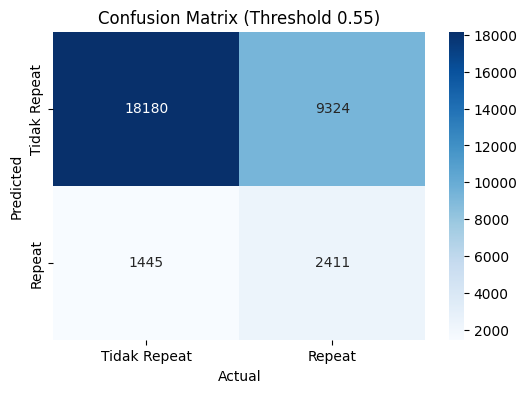

In [16]:
from sklearn.metrics import confusion_matrix

#Membuat confusion matrix untuk melihat jumlah true positive, true negative, false positive, dan false negative berdasarkan threshold yang sudah ditentukan
cm = confusion_matrix(y_test, y_pred_custom) 

plt.figure(figsize=(6,4))
sns.heatmap(cm, 
            annot=True, 
            fmt='d', 
            cmap='Blues',
            xticklabels=['Tidak Repeat', 'Repeat'],
            yticklabels=['Tidak Repeat', 'Repeat'])

plt.title(f'Confusion Matrix (Threshold {custom_threshold})')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()

True Negative

Angkanya naik drastis dari 15.690 (di model sebelumnya) menjadi 18.180. Ini berarti model sekarang jauh lebih pintar dalam mengenali pelanggan biasa.

True Positive

Model ini berhasil mengamankan 2.411 pembeli potensial. Memang angka ini sedikit turun dari model sebelumnya (2.746), namun 2.411 masih merupakan angka konversi yang sangat solid untuk di- follow up oleh tim Sales.

False Positive

Di model sebelumnya, tim Sales harus menelepon 11.814 orang salah sasaran. Sekarang, angkanya turun derastiss menjadi hanya 1.445 orang. Dalam dunia bisnis, model ini menyelamatkan anggaran telemarketing, pulsa, dan waktu perusahaan secara masif.

False Negative

Angka ini melonjak tajam (sebelumnya hanya 1.110). Ini adalah Trade-off (harga yang harus dibayar) demi mendapatkan efisiensi. Model sekarang lebih memilih "melepaskan" prospek yang gelagatnya kurang meyakinkan, daripada membuang budget Sales.